# nuScenes Dataset Tutorial

**Objectives**
- Visualize camera images and object label
- Visualize camera iamges and map label

In [96]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

%matplotlib inline

## Initialize

Initialize dataset and pick a sample

In [97]:
DATASET_PATH = '/mnt/dataset/nuscenes/v1.0-mini'

nusc = NuScenes(version='v1.0-mini', dataroot=DATASET_PATH, verbose=True)
sample = nusc.sample[0]

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 3.548 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


## BEV - Object

[[-37.84757657 -37.62410956 -38.2482933  -38.47176031]
 [-50.88144871 -50.30204946 -50.06130964 -50.64070889]]
[[-32.92246627 -32.20847917 -31.90940359 -32.62339069]
 [-27.74590437 -28.04731344 -27.33885399 -27.03744491]]
[[-55.77407951 -54.98466989 -59.24579036 -60.03519997]
 [-50.36950252 -48.51992056 -46.70125583 -48.5508378 ]]
[[-34.65926423 -35.33954322 -35.68860563 -35.00832665]
 [-22.17318802 -21.85268138 -22.59357033 -22.91407697]]
[[-1.50857998 -1.12497479 -0.96728988 -1.35089508]
 [15.8091393  15.6215865  15.94410235 16.13165515]]
[[-37.84197647 -37.70383431 -39.4378934  -39.57603555]
 [-52.15832338 -51.48331394 -51.12843497 -51.80344441]]
[[-33.09241393 -32.48940798 -32.20145594 -32.80446188]
 [-30.04966535 -30.320414   -29.67909301 -29.40834435]]
[[-0.36738628 -2.00108291 -3.97648359 -2.34278695]
 [22.12656932 22.96657188 19.12467232 18.28466977]]
[[-15.30913055 -15.33707954 -14.62873932 -14.60079033]
 [-58.40939069 -59.05678767 -59.08736766 -58.43997068]]
[[-16.54288288 -1

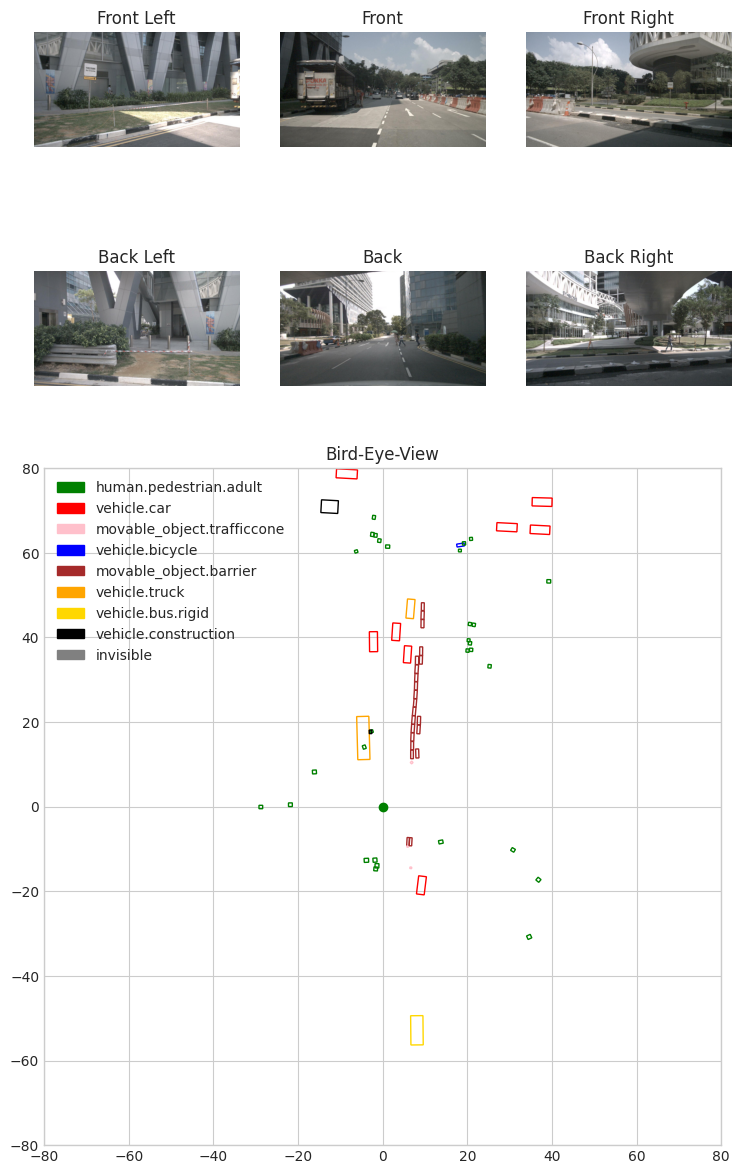

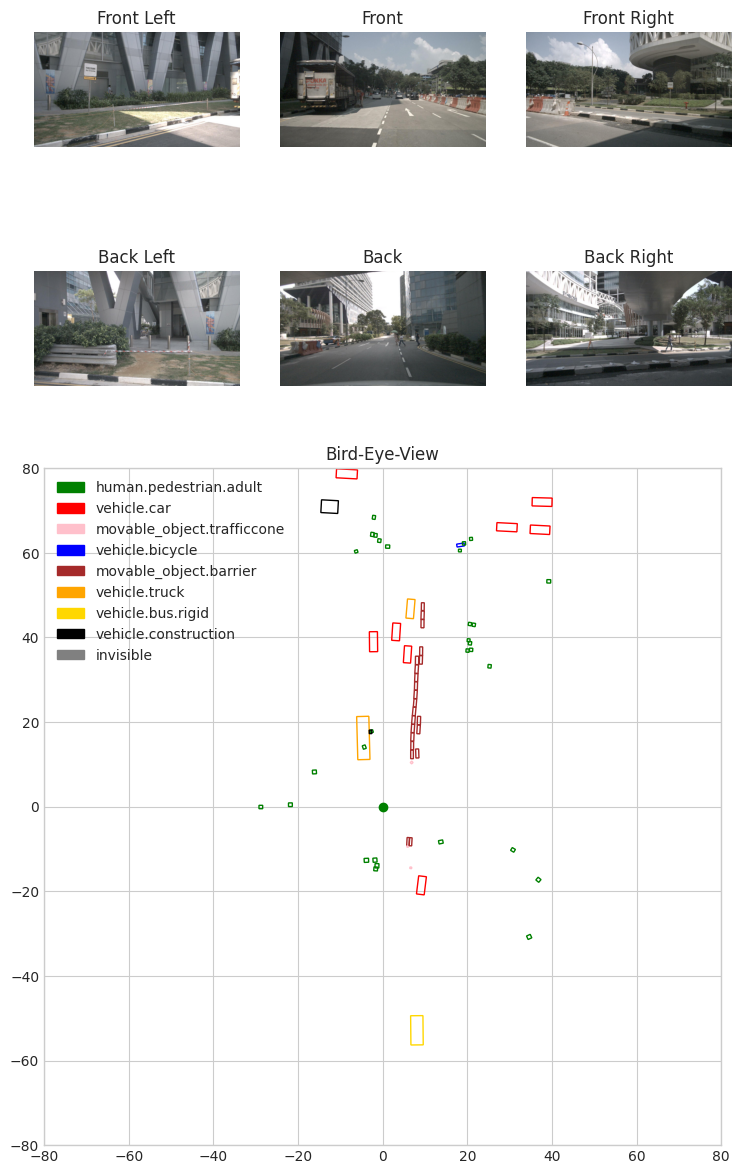

In [113]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

L = 80
fig = plt.figure(figsize=(9, 15))

camera_order = [
    'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT'
]

camera_images = []
for cam in camera_order:
    data = nusc.get('sample_data', sample['data'][cam])
    img = cv2.imread(nusc.dataroot + '/' + data['filename'])
    camera_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

for i, img in enumerate(camera_images):
    ax_cam = fig.add_subplot(5, 3, i+1)
    ax_cam.imshow(img)
    ax_cam.set_title(camera_order[i].replace("CAM_", "").replace("_", " ").title())
    ax_cam.axis('off')
    
object_color = {
    'vehicle.car': 'red',
    'vehicle.truck': 'orange',
    'vehicle.bus.bendy': 'darkorange',
    'vehicle.bus.rigid': 'gold',
    'vehicle.motorcycle': 'purple',
    'vehicle.bicycle': 'blue',
    'human.pedestrian.adult': 'green',
    'human.pedestrian.child': 'lime',
    'movable_object.barrier': 'brown',
    'movable_object.trafficcone': 'pink',
}
default_color = 'black'
invisible_color = 'gray'

gs = gridspec.GridSpec(5, 3, figure=fig)
ax_bev = fig.add_subplot(gs[2:, :])

ax_bev.set_title('Bird-Eye-View')
ax_bev.set_xlim(-L, L)
ax_bev.set_ylim(-L, L)
ax_bev.set_aspect('equal')

# Ego pose
ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
ego_translation = np.array(ego_pose['translation'][0:2])
ego_rotation = Quaternion(ego_pose['rotation'])
yaw_angle = ego_rotation.yaw_pitch_roll[0]  # yaw [rad]

# Rotation matrix: global -> local
def rotate_to_ego_frame(xy, yaw):
    R = np.array([[np.cos(-yaw), -np.sin(-yaw)],
                  [np.sin(-yaw),  np.cos(-yaw)]])
    return R @ xy
    
# Object bounding box
legend_classes = {}
for token in sample['anns']:
    ann = nusc.get('sample_annotation', token)
    box = Box(ann['translation'], ann['size'], Quaternion(ann['rotation']))

    category = ann['category_name']
    color = object_color.get(category, default_color)

    # visibility_token 확인
    if ann['visibility_token'] is not None:
        visibility = nusc.get('visibility', ann['visibility_token'])['level']  # 'v0'-'v3'
        if visibility == 'v0':
            color = invisible_color
    
    corners = box.bottom_corners()[:2] - ego_translation.reshape(2, 1)
    corners = rotate_to_ego_frame(corners, yaw_angle - np.pi/2)
    
    rect = plt.Polygon(corners.T, fill=False, edgecolor=color)
    ax_bev.add_patch(rect)

    if color not in legend_classes:
        legend_classes[color] = category

legend_patches = [
    mpatches.Patch(color=c, label=legend_classes[c]) for c in legend_classes]
legend_patches.append(mpatches.Patch(color='gray', label='invisible'))

ax_bev.plot(0, 0, 'go', label='Ego Vehicle')
ax_bev.legend(handles=legend_patches)

fig

## BEV - Map

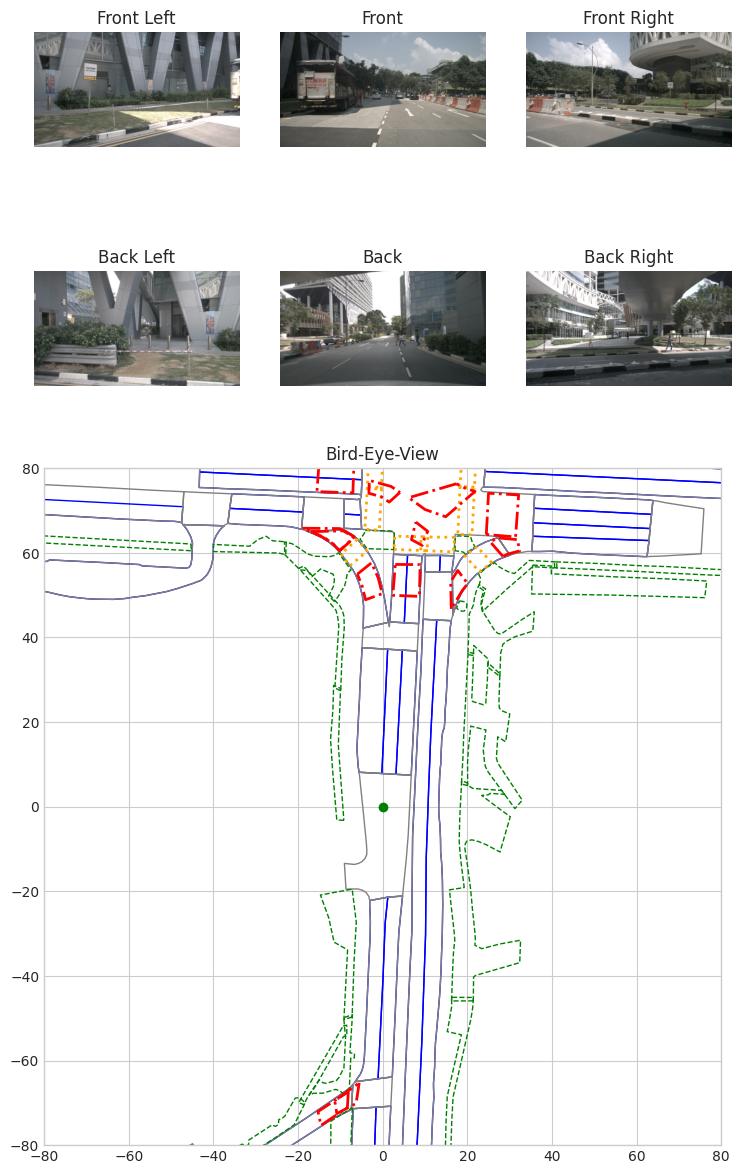

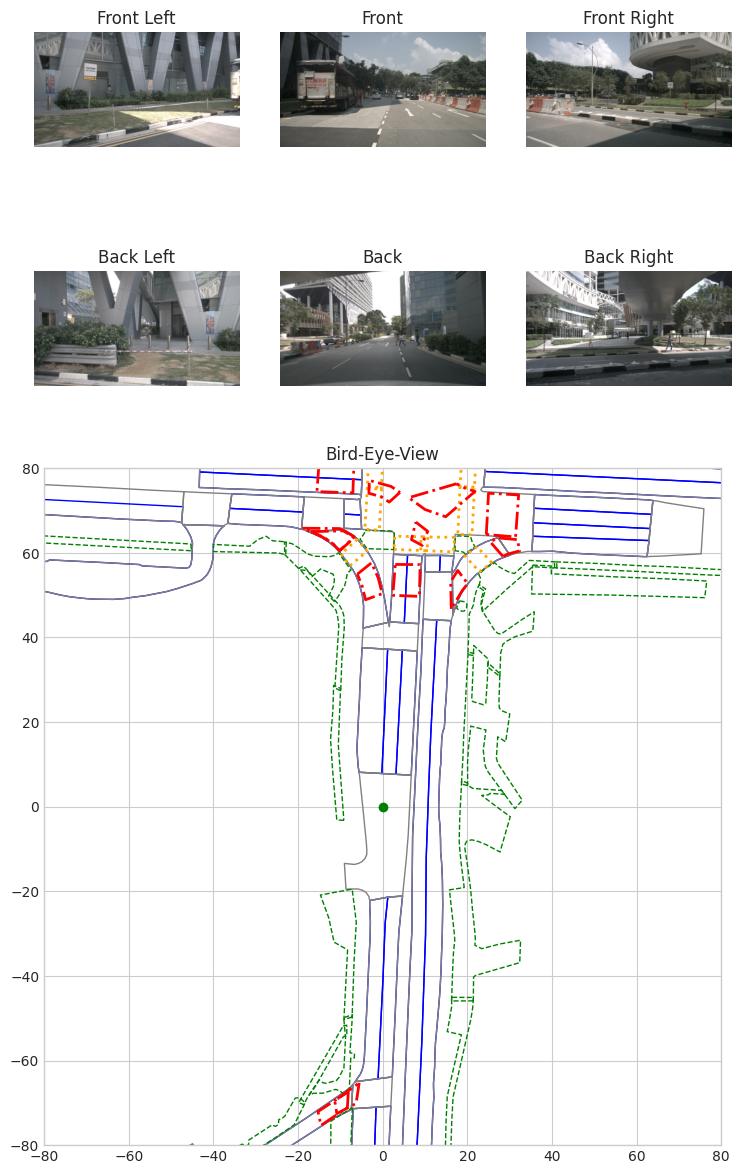

In [119]:
from nuscenes.map_expansion.map_api import NuScenesMap
from shapely.geometry import Polygon, LineString
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

L = 80
fig = plt.figure(figsize=(9, 15))

camera_order = [
    'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT'
]

camera_images = []
for cam in camera_order:
    data = nusc.get('sample_data', sample['data'][cam])
    img = cv2.imread(nusc.dataroot + '/' + data['filename'])
    camera_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

for i, img in enumerate(camera_images):
    ax_cam = fig.add_subplot(5, 3, i+1)
    ax_cam.imshow(img)
    ax_cam.set_title(camera_order[i].replace("CAM_", "").replace("_", " ").title())
    ax_cam.axis('off')

# Ego pose
ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
ego_translation = np.array(ego_pose['translation'][0:2])
ego_rotation = Quaternion(ego_pose['rotation'])
yaw_angle = ego_rotation.yaw_pitch_roll[0]  # yaw [rad]

scene = nusc.get('scene', nusc.sample[0]['scene_token'])
log = nusc.get('log', scene['log_token'])
location = log['location']  # e.g., 'boston-seaport'
nusc_map = NuScenesMap(dataroot=nusc.dataroot, map_name=location)

layers_and_styles = {
    'lane':           {'color': 'blue',   'ls': '-',  'lw': 1},
    'road_segment':   {'color': 'gray',   'ls': '-',  'lw': 1},
    'walkway':        {'color': 'green',  'ls': '--', 'lw': 1},
    'ped_crossing':   {'color': 'orange', 'ls': ':',  'lw': 2},
    'stop_line':      {'color': 'red',    'ls': '-.', 'lw': 2},
}

gs = gridspec.GridSpec(5, 3, figure=fig)
ax_bev = fig.add_subplot(gs[2:, :])

ax_bev.set_title('Bird-Eye-View')
ax_bev.set_xlim(-L, L)
ax_bev.set_ylim(-L, L)
ax_bev.set_aspect('equal')

for layer_name, style in layers_and_styles.items():
    tokens = nusc_map.get_records_in_radius(
        ego_translation[0], ego_translation[1], L, layer_names=[layer_name]
    )[layer_name]

    for token in tokens:
        record = nusc_map.get(layer_name, token)
        polygon_token = record.get('polygon_token')
        line_token = record.get('line_token')
        
        if polygon_token:
            polygon = nusc_map.extract_polygon(polygon_token)
            coords = np.array(polygon.exterior.coords)
        elif line_token:
            line = nusc_map.extract_line(line_token)
            coords = np.array(line.coords)
        else:
            continue

        # local frame 변환
        coords = (coords - ego_translation).T
        coords = rotate_to_ego_frame(coords, yaw_angle - np.pi/2).T  # shape (N, 2)

        # 그리기
        ax_bev.plot(coords[:, 0], coords[:, 1],
                color=style['color'],
                linestyle=style['ls'],
                linewidth=style['lw'],
                label=layer_name)

# ego 표시
ax_bev.plot(0, 0, 'go', label='ego')

# 중복 legend 제거
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax_bev.legend(unique.values(), unique.keys())

fig